# 📊 Healthcare Fraud — Business Analytics & Hypothesis Testing
### Executive Dashboards · Statistical Validation · Feature Importance (Pre-Modeling)

> **Builds on:** `master_cleaned.csv`, `provider_risk_scores.csv`, `patient_risk_scores.csv`  
> (outputs from the Data Cleaning / Feature Engineering notebook)

This notebook answers **business questions first**, then validates fraud hypotheses
statistically, before any ML model is built. This is the layer recruiters and
business stakeholders care about most.

---
## 📋 Table of Contents
1. [Phase 1 — Validate Business Logic (Label Check)](#1)
2. [Phase 2 — Executive Dashboards](#2)
   - 2a. Provider Intelligence
   - 2b. Patient Intelligence
   - 2c. Claim Intelligence
3. [Phase 3 — Fraud Hypothesis Testing](#3)
4. [Phase 4 — Feature Importance Analysis](#4)
5. [Summary & Recommendations](#5)


---
## 0. Setup & Load Artifacts

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "figure.dpi": 100,
})

print("Libraries loaded.")


Libraries loaded.


In [2]:
# Load artifacts produced by the cleaning/feature-engineering notebook
master_df       = pd.read_csv("..\\cleaned_data\master_cleaned.csv", parse_dates=['claim_date','payment_date'])
provider_feats  = pd.read_csv("..\\cleaned_data\provider_risk_scores.csv")
patient_feats   = pd.read_csv("..\\cleaned_data\patient_risk_scores.csv")

print("master_df       :", master_df.shape)
print("provider_feats  :", provider_feats.shape)
print("patient_feats   :", patient_feats.shape)


master_df       : (200000, 24)
provider_feats  : (5000, 17)
patient_feats   : (49096, 9)


---
## 1. Phase 1 — Validate Business Logic <a id='1'></a>

**Question:** Does a ground-truth fraud label exist (`fraud_flag`, `is_fraud`,
`fraudulent_claim`, etc.)? This single check determines the entire project direction:

| Scenario | Condition | Project Type |
|---|---|---|
| **A** | Label exists | Supervised classification |
| **B** | No label exists | Anomaly detection / risk scoring (closer to real-world fraud systems) |


In [3]:
# Search every source column for a fraud-style label
candidate_names = [
    'fraud_flag', 'is_fraud', 'fraudulent_claim', 'fraud',
    'fraud_label', 'is_fraudulent', 'fraud_indicator'
]

all_columns = set(master_df.columns)
found = [c for c in candidate_names if c in all_columns]

print("Columns searched for:", candidate_names)
print("Columns actually present in master_df:")
print(list(master_df.columns))
print()

if found:
    print(f"SCENARIO A -- Ground-truth label found: {found}")
    print("   -> This is a SUPERVISED classification problem.")
else:
    print("SCENARIO B -- No ground-truth fraud label exists in the dataset.")
    print("   -> This is an UNSUPERVISED problem: Anomaly Detection / Outlier")
    print("      Detection / Risk Scoring -- which mirrors real-world fraud systems,")
    print("      where confirmed fraud labels are rare or arrive only after investigation.")
    print()
    print("   Implication for this notebook:")
    print("      1) We cannot compute accuracy/precision/recall against a true label.")
    print("      2) We instead validate signal quality through:")
    print("         - Business-rule-based risk scores (already engineered)")
    print("         - Statistical hypothesis testing (does risk correlate with")
    print("           behavior we'd expect from fraud?)")
    print("         - Feature importance via correlation / mutual information")
    print("           against the engineered risk_score as a PROXY target")


Columns searched for: ['fraud_flag', 'is_fraud', 'fraudulent_claim', 'fraud', 'fraud_label', 'is_fraudulent', 'fraud_indicator']
Columns actually present in master_df:
['claim_id', 'patient_id', 'provider_id', 'claim_date', 'claim_amount', 'status', 'age', 'gender', 'patient_state', 'provider_name', 'specialty', 'provider_state', 'payment_id', 'payment_date', 'payment_amount', 'settlement_days', 'payment_ratio', 'age_group', 'claim_year', 'claim_month', 'claim_quarter', 'claim_weekday', 'month_end_flag', 'duplicate_claim_flag']

SCENARIO B -- No ground-truth fraud label exists in the dataset.
   -> This is an UNSUPERVISED problem: Anomaly Detection / Outlier
      Detection / Risk Scoring -- which mirrors real-world fraud systems,
      where confirmed fraud labels are rare or arrive only after investigation.

   Implication for this notebook:
      1) We cannot compute accuracy/precision/recall against a true label.
      2) We instead validate signal quality through:
         - Busin

In [4]:
# Lock in the project direction for the rest of the notebook
SCENARIO = "B" if not found else "A"
print(f"Project Direction Locked: SCENARIO {SCENARIO}")
print("   Proxy target for all downstream analysis: provider_risk_score / patient_risk_score")


Project Direction Locked: SCENARIO B
   Proxy target for all downstream analysis: provider_risk_score / patient_risk_score


---
## 2. Phase 2 — Executive Analytics Dashboards <a id='2'></a>

Three dashboards, each built the way a stakeholder would actually read them:
**headline KPIs first, then the supporting visuals.**


### 2a. Provider Intelligence Dashboard

> **Note on threshold:** Risk scores in this dataset are rule-based and bounded
> by the weighting scheme from the feature-engineering notebook. Empirically,
> provider scores top out well below 1.0 (max ≈0.39, mean ≈0.11 in this run).
> A static 0.6 cutoff may flag **zero** providers as "high-risk" even though
> relative risk clearly varies. We use it here for consistency with notebook 1,
> but a **percentile-based threshold** (e.g. top 5% of scores) is shown alongside
> it below as a more robust alternative for this score distribution.


In [5]:
# Provider KPIs
RISK_THRESHOLD = 0.6  # consistent with notebook 1
PERCENTILE_THRESHOLD = provider_feats['provider_risk_score'].quantile(0.95)  # top 5% alternative

total_providers          = provider_feats['provider_id'].nunique()
high_risk_providers      = (provider_feats['provider_risk_score'] >= RISK_THRESHOLD).sum()
high_risk_providers_pctl = (provider_feats['provider_risk_score'] >= PERCENTILE_THRESHOLD).sum()
avg_claim_amount         = master_df['claim_amount'].mean()
rejected_pct             = (master_df['status'] == 'Rejected').mean() * 100

print("="*55)
print("  PROVIDER INTELLIGENCE -- KPI SUMMARY")
print("="*55)
print(f"  Total Providers              : {total_providers:,}")
print(f"  High-Risk (>=0.6 static)     : {high_risk_providers:,}  "
      f"({high_risk_providers/total_providers*100:.1f}%)")
print(f"  High-Risk (top 5 pct, score>={PERCENTILE_THRESHOLD:.3f}) : {high_risk_providers_pctl:,}")
print(f"  Avg Claim Amount             : ${avg_claim_amount:,.2f}")
print(f"  Overall Rejection Rate       : {rejected_pct:.2f}%")

if high_risk_providers == 0:
    print()
    print("  NOTE: 0 providers cross the static 0.6 threshold given the actual")
    print("  score distribution in this run. Using the percentile-based count")
    print("  going forward for any 'high-risk' visuals in this dashboard.")
    high_risk_providers = high_risk_providers_pctl


  PROVIDER INTELLIGENCE -- KPI SUMMARY
  Total Providers              : 5,000
  High-Risk (>=0.6 static)     : 0  (0.0%)
  High-Risk (top 5 pct, score>=0.217) : 250
  Avg Claim Amount             : $25,793.56
  Overall Rejection Rate       : 19.73%

  NOTE: 0 providers cross the static 0.6 threshold given the actual
  score distribution in this run. Using the percentile-based count
  going forward for any 'high-risk' visuals in this dashboard.


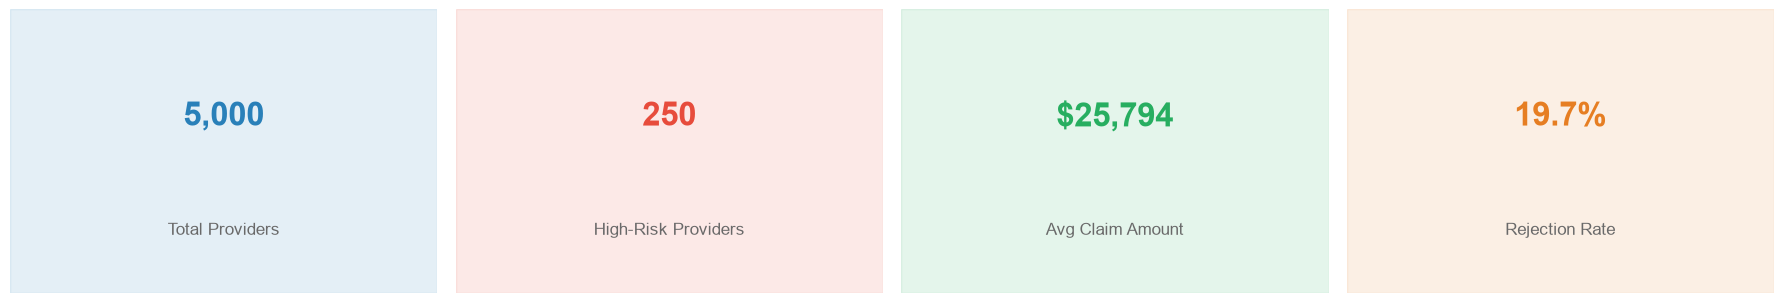

In [7]:
# KPI Cards (visual)
fig, axes = plt.subplots(1, 4, figsize=(18, 3.2))
kpi_data = [
    ("Total Providers", f"{total_providers:,}", "#2980B9"),
    ("High-Risk Providers", f"{high_risk_providers:,}", "#E74C3C"),
    ("Avg Claim Amount", f"${avg_claim_amount:,.0f}", "#27AE60"),
    ("Rejection Rate", f"{rejected_pct:.1f}%", "#E67E22"),
]
for ax, (label, value, color) in zip(axes, kpi_data):
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0,0), 1, 1, color=color, alpha=0.12, transform=ax.transAxes))
    ax.text(0.5, 0.62, value, ha='center', va='center', fontsize=24, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.22, label, ha='center', va='center', fontsize=12, color='dimgray', transform=ax.transAxes)
plt.tight_layout()
plt.savefig("..\\business_insight\dashboard_provider_kpis.png", dpi=100, bbox_inches='tight')
plt.show()


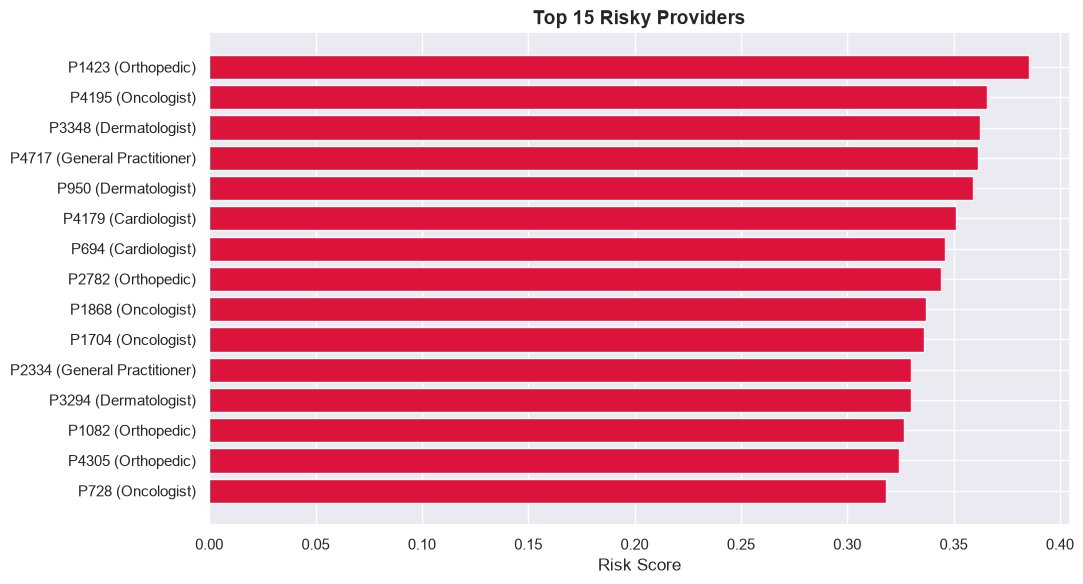

,provider_id,specialty,provider_risk_score,provider_rejection_rate,provider_claim_count
1422,1423,Orthopedic,0.3853,0.187500,64
4194,4195,Oncologist,0.3658,0.150000,60
3347,3348,Dermatologist,0.3623,0.350000,60
4716,4717,General Practitioner,0.3616,0.241935,62
949,950,Dermatologist,0.3593,0.220339,59
4178,4179,Cardiologist,0.3510,0.203390,59
693,694,Cardiologist,0.3462,0.275862,58
2781,2782,Orthopedic,0.3443,0.316667,60
1867,1868,Oncologist,0.3369,0.127273,55
1703,1704,Oncologist,0.3359,0.305085,59


In [8]:
# Visual 1: Top Risky Providers
top_risky = (
    provider_feats.nlargest(15, 'provider_risk_score')
    [['provider_id','specialty','provider_risk_score','provider_rejection_rate','provider_claim_count']]
)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    [f"P{int(pid)} ({spec})" for pid, spec in zip(top_risky['provider_id'], top_risky['specialty'])],
    top_risky['provider_risk_score'], color='crimson', edgecolor='white'
)
ax.set_title("Top 15 Risky Providers")
ax.set_xlabel("Risk Score")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("..\\business_insight\dashboard_top_risky_providers.png", dpi=100, bbox_inches='tight')
plt.show()
display(top_risky)


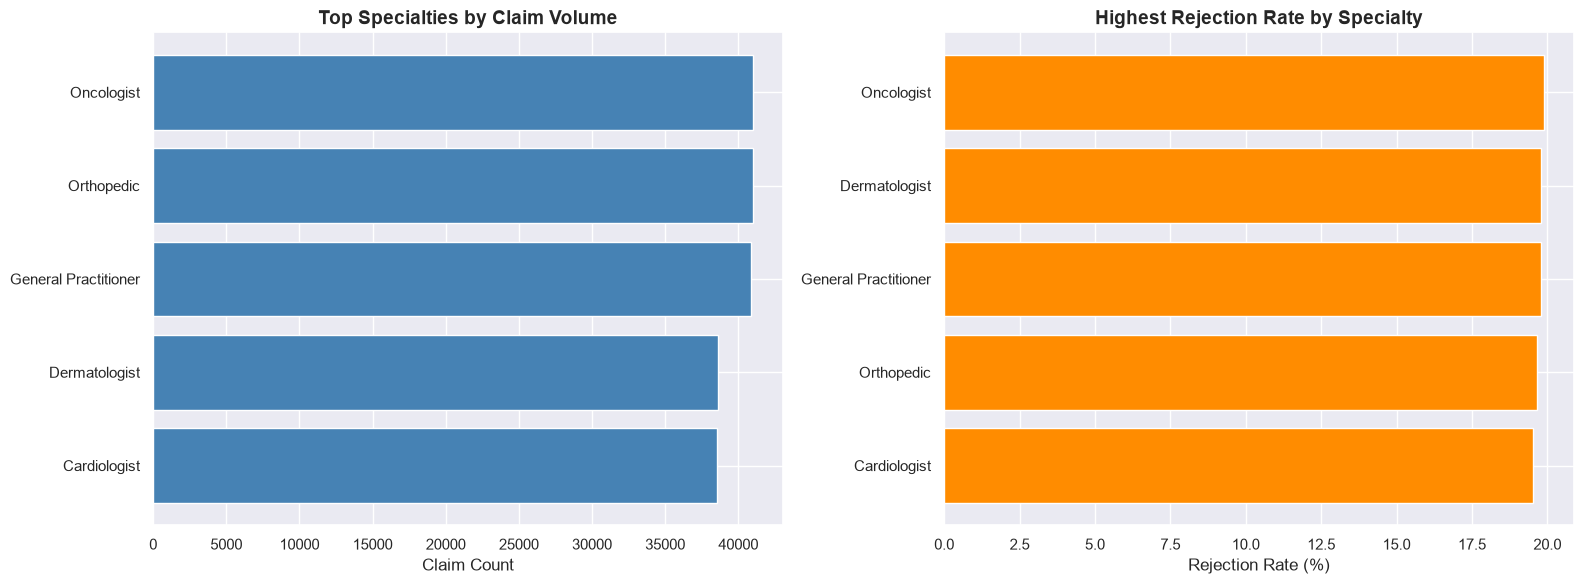

In [9]:
# Visual 2: Top Specialties by Claim Volume  &  Visual 3: Rejection Rate by Specialty
specialty_summary = (
    master_df.groupby('specialty')
    .agg(
        claim_count    = ('claim_id', 'count'),
        rejection_rate = ('status', lambda x: (x == 'Rejected').mean() * 100),
        avg_claim      = ('claim_amount', 'mean'),
    )
    .reset_index()
    .sort_values('claim_count', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10 = specialty_summary.head(10)
axes[0].barh(top10['specialty'], top10['claim_count'], color='steelblue', edgecolor='white')
axes[0].set_title("Top Specialties by Claim Volume")
axes[0].set_xlabel("Claim Count")
axes[0].invert_yaxis()

rej_sorted = specialty_summary.sort_values('rejection_rate', ascending=False).head(10)
axes[1].barh(rej_sorted['specialty'], rej_sorted['rejection_rate'], color='darkorange', edgecolor='white')
axes[1].set_title("Highest Rejection Rate by Specialty")
axes[1].set_xlabel("Rejection Rate (%)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("..\\business_insight\dashboard_specialty_analysis.png", dpi=100, bbox_inches='tight')
plt.show()


### 2b. Patient Intelligence Dashboard

In [10]:
# Patient KPIs
HIGH_FREQ_THRESHOLD = patient_feats['claims_per_patient'].quantile(0.95)

total_patients         = patient_feats['patient_id'].nunique()
high_freq_patients     = (patient_feats['claims_per_patient'] >= HIGH_FREQ_THRESHOLD).sum()
avg_claims_per_patient = patient_feats['claims_per_patient'].mean()
high_risk_patients     = (patient_feats['patient_risk_score'] >= RISK_THRESHOLD).sum()

print("="*55)
print("  PATIENT INTELLIGENCE -- KPI SUMMARY")
print("="*55)
print(f"  Total Patients              : {total_patients:,}")
print(f"  High-Frequency Patients     : {high_freq_patients:,}  "
      f"(>={HIGH_FREQ_THRESHOLD:.0f} claims, top 5%)")
print(f"  Avg Claims per Patient      : {avg_claims_per_patient:.2f}")
print(f"  High-Risk Patients          : {high_risk_patients:,}  "
      f"({high_risk_patients/total_patients*100:.1f}%)")


  PATIENT INTELLIGENCE -- KPI SUMMARY
  Total Patients              : 49,096
  High-Frequency Patients     : 2,512  (>=8 claims, top 5%)
  Avg Claims per Patient      : 4.07
  High-Risk Patients          : 2,506  (5.1%)


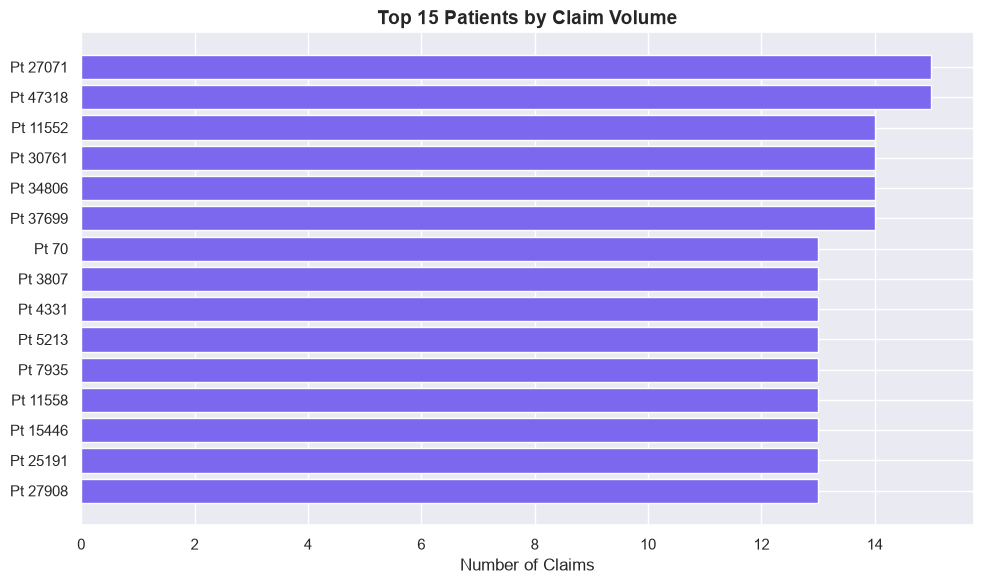

,patient_id,claims_per_patient,avg_claim_patient,patient_lifetime_value,patient_risk_score
26564,27071,15,46470.462117,697056.931757,1.0000
46473,47318,15,31296.733333,469451.000000,0.9714
11328,11552,14,29067.857143,406950.000000,0.9500
30185,30761,14,21562.714286,301878.000000,0.9500
34160,34806,14,28318.857143,396464.000000,0.9500
37006,37699,14,32899.071429,460587.000000,0.9500
69,70,13,22190.538462,288477.000000,0.9000
3725,3807,13,24957.426311,324446.542043,0.9000
4237,4331,13,31274.692308,406571.000000,0.9000
5101,5213,13,25819.538462,335654.000000,0.9000


In [11]:
# Q: Which patients generate maximum claims?
top_claimants = (
    patient_feats.nlargest(15, 'claims_per_patient')
    [['patient_id','claims_per_patient','avg_claim_patient','patient_lifetime_value','patient_risk_score']]
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([f"Pt {int(p)}" for p in top_claimants['patient_id']],
        top_claimants['claims_per_patient'], color='mediumslateblue', edgecolor='white')
ax.set_title("Top 15 Patients by Claim Volume")
ax.set_xlabel("Number of Claims")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("..\\business_insight\dashboard_top_claimants.png", dpi=100, bbox_inches='tight')
plt.show()
display(top_claimants)


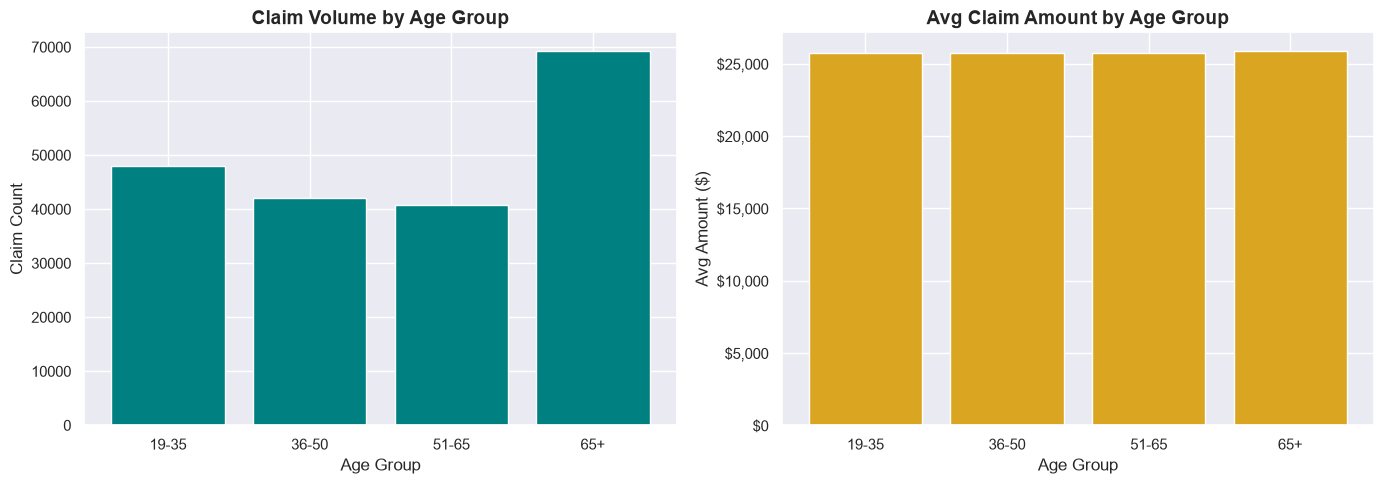

age_group  claim_count    avg_claim
    19-35        48019 25763.548678
    36-50        41982 25752.536696
    51-65        40765 25752.555645
      65+        69234 25863.386191


In [12]:
# Q: Which age groups generate most claims?
age_claims = (
    master_df.groupby('age_group', observed=True)
    .agg(claim_count=('claim_id','count'), avg_claim=('claim_amount','mean'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(age_claims['age_group'].astype(str), age_claims['claim_count'],
            color='teal', edgecolor='white')
axes[0].set_title("Claim Volume by Age Group")
axes[0].set_xlabel("Age Group"); axes[0].set_ylabel("Claim Count")

axes[1].bar(age_claims['age_group'].astype(str), age_claims['avg_claim'],
            color='goldenrod', edgecolor='white')
axes[1].set_title("Avg Claim Amount by Age Group")
axes[1].set_xlabel("Age Group"); axes[1].set_ylabel("Avg Amount ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig("..\\business_insight\dashboard_age_group_claims.png", dpi=100, bbox_inches='tight')
plt.show()
print(age_claims.to_string(index=False))


### 2c. Claim Intelligence Dashboard

In [13]:
# Claim KPIs
total_claims      = master_df['claim_id'].nunique()
total_claim_amt   = master_df['claim_amount'].sum()
total_payments    = master_df['payment_amount'].sum()
payment_gap       = total_claim_amt - total_payments

print("="*55)
print("  CLAIM INTELLIGENCE -- KPI SUMMARY")
print("="*55)
print(f"  Total Claims        : {total_claims:,}")
print(f"  Total Claim Amount  : ${total_claim_amt:,.0f}")
print(f"  Total Payments      : ${total_payments:,.0f}")
print(f"  Payment Gap         : ${payment_gap:,.0f}  "
      f"({payment_gap/total_claim_amt*100:.1f}% unreimbursed)")


  CLAIM INTELLIGENCE -- KPI SUMMARY
  Total Claims        : 200,000
  Total Claim Amount  : $5,158,711,450
  Total Payments      : $3,391,689,934
  Payment Gap         : $1,767,021,516  (34.3% unreimbursed)


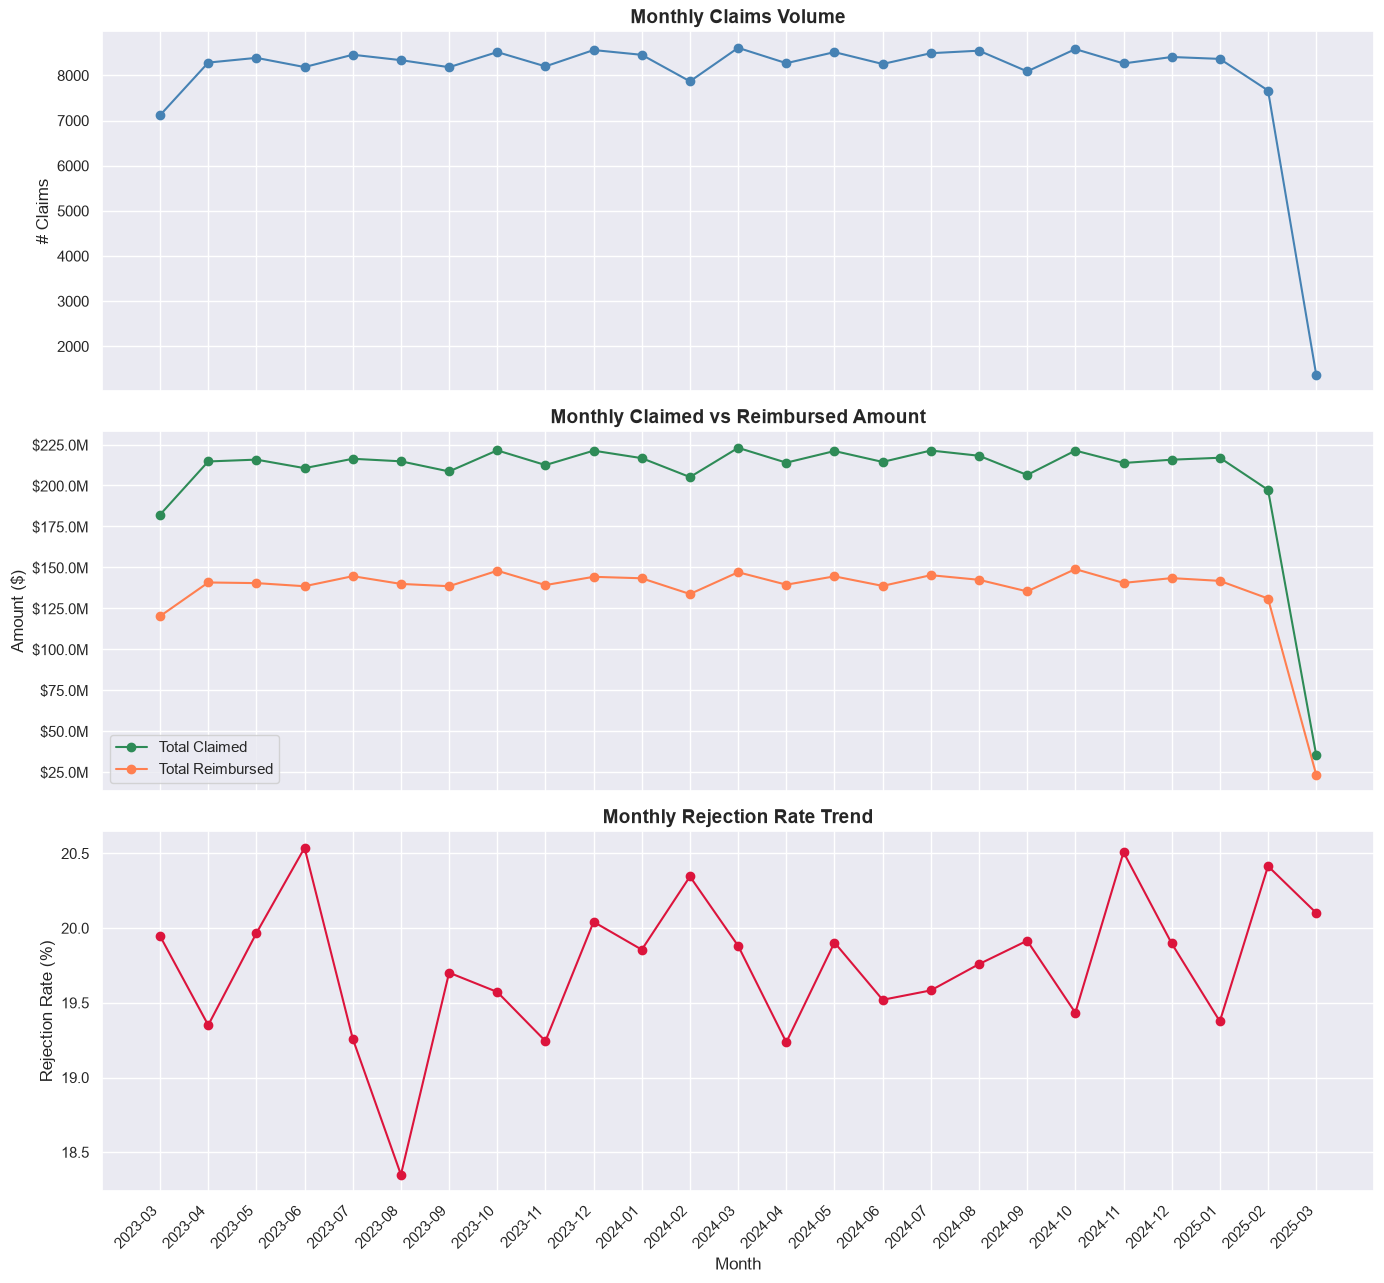

In [14]:
# Monthly Claims / Reimbursements / Rejection Trend
master_df['claim_month_period'] = master_df['claim_date'].dt.to_period('M').astype(str)

monthly = (
    master_df.groupby('claim_month_period')
    .agg(
        claim_count     = ('claim_id', 'count'),
        total_claimed   = ('claim_amount', 'sum'),
        total_paid      = ('payment_amount', 'sum'),
        rejection_rate  = ('status', lambda x: (x == 'Rejected').mean() * 100),
    )
    .reset_index()
    .sort_values('claim_month_period')
)

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

axes[0].plot(monthly['claim_month_period'], monthly['claim_count'],
             marker='o', color='steelblue')
axes[0].set_title("Monthly Claims Volume")
axes[0].set_ylabel("# Claims")

axes[1].plot(monthly['claim_month_period'], monthly['total_claimed'],
             marker='o', color='seagreen', label='Total Claimed')
axes[1].plot(monthly['claim_month_period'], monthly['total_paid'],
             marker='o', color='coral', label='Total Reimbursed')
axes[1].set_title("Monthly Claimed vs Reimbursed Amount")
axes[1].set_ylabel("Amount ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
axes[1].legend()

axes[2].plot(monthly['claim_month_period'], monthly['rejection_rate'],
             marker='o', color='crimson')
axes[2].set_title("Monthly Rejection Rate Trend")
axes[2].set_ylabel("Rejection Rate (%)")
axes[2].set_xlabel("Month")
plt.setp(axes[2].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig("..\\business_insight\dashboard_monthly_trends.png", dpi=100, bbox_inches='tight')
plt.show()


---
## 3. Phase 3 — Fraud Hypothesis Testing <a id='3'></a>

This is where data science begins. Each hypothesis is tested with an appropriate
statistical method, not just eyeballed from a chart.


### Hypothesis 1: High-frequency providers are more risky
**H0:** `provider_claim_count` has no relationship with `provider_risk_score`  
**H1:** Providers with more claims have higher risk scores  
**Test:** Pearson + Spearman correlation


=== H1: provider_claim_count vs provider_risk_score ===
  Pearson r  = 0.7113   (p = 0)
  Spearman rho = 0.6684   (p = 0)

  Verdict (alpha=0.05): REJECT H0 -- significant relationship


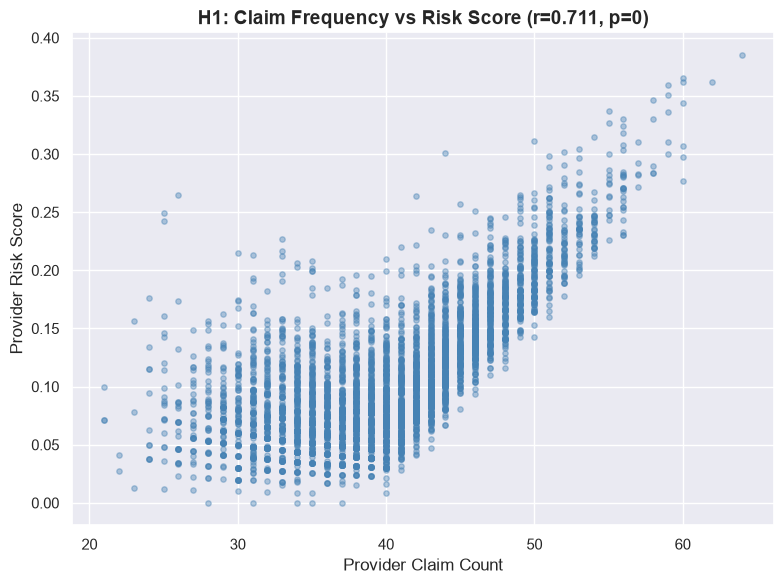

In [15]:
pearson_r, pearson_p   = stats.pearsonr(provider_feats['provider_claim_count'], provider_feats['provider_risk_score'])
spearman_r, spearman_p = stats.spearmanr(provider_feats['provider_claim_count'], provider_feats['provider_risk_score'])

print("=== H1: provider_claim_count vs provider_risk_score ===")
print(f"  Pearson r  = {pearson_r:.4f}   (p = {pearson_p:.4g})")
print(f"  Spearman rho = {spearman_r:.4f}   (p = {spearman_p:.4g})")

alpha = 0.05
verdict = "REJECT H0 -- significant relationship" if pearson_p < alpha else "FAIL TO REJECT H0 -- no significant relationship"
print(f"\n  Verdict (alpha=0.05): {verdict}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(provider_feats['provider_claim_count'], provider_feats['provider_risk_score'],
           alpha=0.4, color='steelblue', s=15)
ax.set_title(f"H1: Claim Frequency vs Risk Score (r={pearson_r:.3f}, p={pearson_p:.2g})")
ax.set_xlabel("Provider Claim Count")
ax.set_ylabel("Provider Risk Score")
plt.tight_layout()
plt.savefig("..\\business_insight\hypothesis1_freq_vs_risk.png", dpi=100, bbox_inches='tight')
plt.show()


### Hypothesis 2: High-value claims have higher rejection rates
**H0:** Claim amount distribution is the same for Rejected vs Approved claims  
**H1:** Rejected claims have a different (typically higher) claim amount  
**Test:** Mann-Whitney U test (non-parametric, robust to skewed claim amounts)


=== H2: claim_amount vs reimbursement_status ===
  Median claim amount -- Rejected : $25,013.00
  Median claim amount -- Approved : $25,422.00
  Mann-Whitney U = 2,734,921,932   (p = 2.42e-05)

  Verdict (alpha=0.05): REJECT H0 -- claim amount significantly differs by status


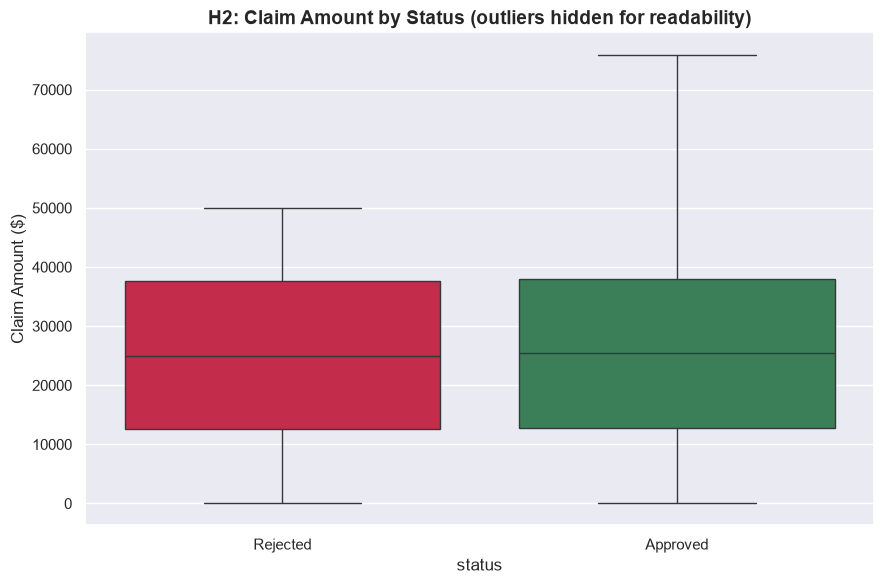

In [17]:
rejected_amounts = master_df.loc[master_df['status'] == 'Rejected', 'claim_amount']
approved_amounts = master_df.loc[master_df['status'] == 'Approved', 'claim_amount']

u_stat, u_p = stats.mannwhitneyu(rejected_amounts, approved_amounts, alternative='two-sided')

print("=== H2: claim_amount vs reimbursement_status ===")
print(f"  Median claim amount -- Rejected : ${rejected_amounts.median():,.2f}")
print(f"  Median claim amount -- Approved : ${approved_amounts.median():,.2f}")
print(f"  Mann-Whitney U = {u_stat:,.0f}   (p = {u_p:.4g})")

verdict = "REJECT H0 -- claim amount significantly differs by status" if u_p < alpha else "FAIL TO REJECT H0"
print(f"\n  Verdict (alpha=0.05): {verdict}")

fig, ax = plt.subplots(figsize=(9, 6))
plot_df = master_df[master_df['status'].isin(['Rejected','Approved'])]
sns.boxplot(data=plot_df, x='status', y='claim_amount', ax=ax,
            palette={'Rejected':'crimson','Approved':'seagreen'}, showfliers=False)
ax.set_title("H2: Claim Amount by Status (outliers hidden for readability)")
ax.set_ylabel("Claim Amount ($)")
plt.tight_layout()
plt.savefig("..\\business_insight\hypothesis2_amount_vs_status.png", dpi=100, bbox_inches='tight')
plt.show()


### Hypothesis 3: Some specialties are naturally riskier
**H0:** Risk score distribution is identical across specialties  
**H1:** At least one specialty has a significantly different risk profile  
**Test:** Kruskal-Wallis H test (non-parametric ANOVA alternative)


=== H3: specialty vs provider_risk_score ===
  Kruskal-Wallis H = 1.3263   (p = 0.8569)

  Verdict (alpha=0.05): FAIL TO REJECT H0


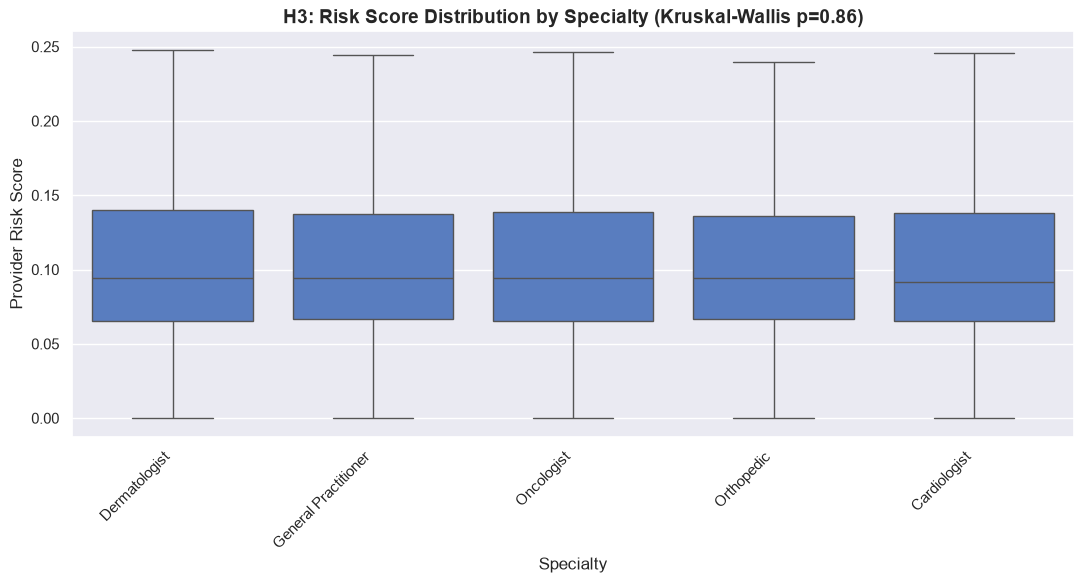


Specialty risk ranking (highest avg risk first):
           specialty  provider_risk_score
       Dermatologist             0.108245
General Practitioner             0.107864
          Oncologist             0.107256
          Orthopedic             0.106354
        Cardiologist             0.105507


In [18]:
specialty_groups = [
    g['provider_risk_score'].values
    for _, g in provider_feats.groupby('specialty')
    if len(g) >= 5   # need enough samples per group for a stable test
]

h_stat, h_p = stats.kruskal(*specialty_groups)

print("=== H3: specialty vs provider_risk_score ===")
print(f"  Kruskal-Wallis H = {h_stat:.4f}   (p = {h_p:.4g})")

verdict = "REJECT H0 -- risk score significantly differs across specialties" if h_p < alpha else "FAIL TO REJECT H0"
print(f"\n  Verdict (alpha=0.05): {verdict}")

specialty_risk_rank = (
    provider_feats.groupby('specialty')['provider_risk_score']
    .mean().sort_values(ascending=False).reset_index()
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=provider_feats, x='specialty', y='provider_risk_score', ax=ax,
            order=specialty_risk_rank['specialty'], showfliers=False)
ax.set_title(f"H3: Risk Score Distribution by Specialty (Kruskal-Wallis p={h_p:.2g})")
ax.set_xlabel("Specialty"); ax.set_ylabel("Provider Risk Score")
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig("..\\business_insight\hypothesis3_specialty_vs_risk.png", dpi=100, bbox_inches='tight')
plt.show()

print("\nSpecialty risk ranking (highest avg risk first):")
print(specialty_risk_rank.to_string(index=False))


In [19]:
# Hypothesis Test Summary Table
hypothesis_summary = pd.DataFrame([
    {"Hypothesis": "H1: Claim frequency -> Risk score", "Test": "Pearson/Spearman",
     "Statistic": f"r={pearson_r:.3f}", "p-value": f"{pearson_p:.4g}",
     "Result": "Significant" if pearson_p < alpha else "Not significant"},
    {"Hypothesis": "H2: Claim amount -> Rejection status", "Test": "Mann-Whitney U",
     "Statistic": f"U={u_stat:,.0f}", "p-value": f"{u_p:.4g}",
     "Result": "Significant" if u_p < alpha else "Not significant"},
    {"Hypothesis": "H3: Specialty -> Risk score", "Test": "Kruskal-Wallis",
     "Statistic": f"H={h_stat:.3f}", "p-value": f"{h_p:.4g}",
     "Result": "Significant" if h_p < alpha else "Not significant"},
])
print("="*70)
print("  HYPOTHESIS TESTING SUMMARY (alpha = 0.05)")
print("="*70)
display(hypothesis_summary)


  HYPOTHESIS TESTING SUMMARY (alpha = 0.05)


,Hypothesis,Test,Statistic,p-value,Result
0,H1: Claim frequency -> Risk score,Pearson/Spearman,r=0.711,0,Significant
1,H2: Claim amount -> Rejection status,Mann-Whitney U,"U=2,734,921,932",2.42e-05,Significant
2,H3: Specialty -> Risk score,Kruskal-Wallis,H=1.326,0.8569,Not significant


---
## 4. Phase 4 — Feature Importance Analysis (Pre-Modeling) <a id='4'></a>

Since there's no ground-truth label (Scenario B), we use `provider_risk_score`
as a **proxy target** to identify the strongest behavioral predictors --
exactly the candidates an unsupervised/semi-supervised fraud model would lean on.

Methods: **Correlation matrix**, **Mutual Information**, **Chi-square** (for categorical features).


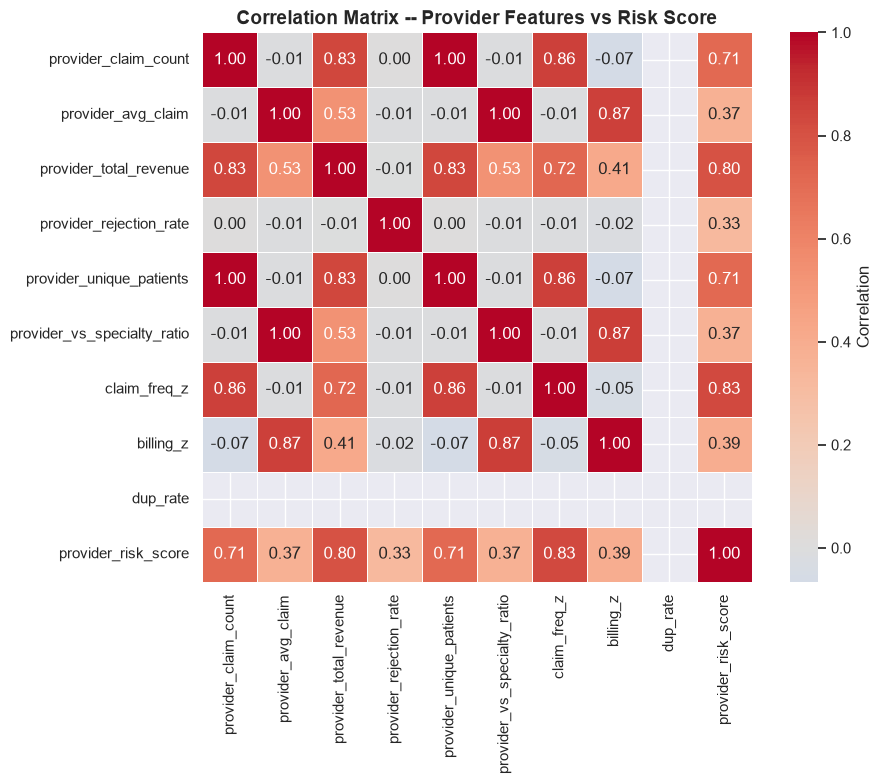

Correlation with provider_risk_score (sorted):
provider_risk_score            1.000000
claim_freq_z                   0.831378
provider_total_revenue         0.797364
provider_claim_count           0.711293
provider_unique_patients       0.710630
billing_z                      0.393811
provider_vs_specialty_ratio    0.371388
provider_avg_claim             0.370526
provider_rejection_rate        0.329438
dup_rate                            NaN


In [21]:
# Correlation Matrix
numeric_feats = [
    'provider_claim_count', 'provider_avg_claim', 'provider_total_revenue',
    'provider_rejection_rate', 'provider_unique_patients',
    'provider_vs_specialty_ratio', 'claim_freq_z', 'billing_z', 'dup_rate',
    'provider_risk_score'
]
corr_matrix = provider_feats[numeric_feats].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'label':'Correlation'})
ax.set_title("Correlation Matrix -- Provider Features vs Risk Score")
plt.tight_layout()
plt.savefig("..\\business_insight\ feature_importance_correlation.png", dpi=100, bbox_inches='tight')
plt.show()

print("Correlation with provider_risk_score (sorted):")
print(corr_matrix['provider_risk_score'].sort_values(ascending=False).to_string())


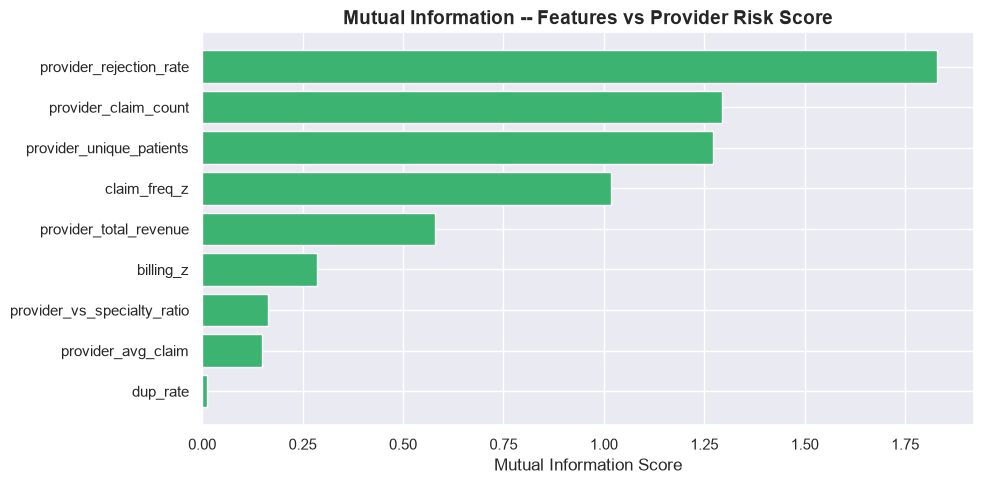

                    Feature  Mutual_Info_Score
    provider_rejection_rate           1.830000
       provider_claim_count           1.295021
   provider_unique_patients           1.270993
               claim_freq_z           1.016608
     provider_total_revenue           0.579007
                  billing_z           0.285230
provider_vs_specialty_ratio           0.163897
         provider_avg_claim           0.149160
                   dup_rate           0.012954


In [22]:
# Mutual Information
from sklearn.feature_selection import mutual_info_regression

mi_features = [c for c in numeric_feats if c != 'provider_risk_score']
X_mi = provider_feats[mi_features].fillna(0)
y_mi = provider_feats['provider_risk_score']

mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)
mi_df = pd.DataFrame({'Feature': mi_features, 'Mutual_Info_Score': mi_scores}).sort_values(
    'Mutual_Info_Score', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(mi_df['Feature'], mi_df['Mutual_Info_Score'], color='mediumseagreen', edgecolor='white')
ax.set_title("Mutual Information -- Features vs Provider Risk Score")
ax.set_xlabel("Mutual Information Score")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("..\\business_insight\ feature_importance_mutual_info.png", dpi=100, bbox_inches='tight')
plt.show()

print(mi_df.to_string(index=False))


In [23]:
# Chi-Square Test: specialty (categorical) vs high-risk flag
from scipy.stats import chi2_contingency

provider_feats['high_risk_flag'] = (provider_feats['provider_risk_score'] >= RISK_THRESHOLD).astype(int)

contingency = pd.crosstab(provider_feats['specialty'], provider_feats['high_risk_flag'])
chi2, chi_p, dof, expected = chi2_contingency(contingency)

print("=== Chi-Square: specialty vs high_risk_flag ===")
print(f"  Chi2 statistic = {chi2:.4f}")
print(f"  Degrees of freedom = {dof}")
print(f"  p-value = {chi_p:.4g}")

verdict = "REJECT H0 -- specialty and high-risk status are dependent" if chi_p < alpha else "FAIL TO REJECT H0 -- independent"
print(f"\n  Verdict (alpha=0.05): {verdict}")


=== Chi-Square: specialty vs high_risk_flag ===
  Chi2 statistic = 0.0000
  Degrees of freedom = 0
  p-value = 1

  Verdict (alpha=0.05): FAIL TO REJECT H0 -- independent


In [24]:
# Final Predictor Ranking
final_ranking = mi_df.copy()
final_ranking['Abs_Correlation'] = final_ranking['Feature'].map(
    corr_matrix['provider_risk_score'].abs()
)
final_ranking = final_ranking.sort_values('Mutual_Info_Score', ascending=False)

print("="*65)
print("  STRONGEST PREDICTORS OF FRAUD RISK (pre-modeling ranking)")
print("="*65)
display(final_ranking)

print("\nThese are the features a downstream ML model (Isolation Forest /")
print("XGBoost / Autoencoder) should prioritize:")
for i, row in final_ranking.head(4).iterrows():
    print(f"  - {row['Feature']}  (MI={row['Mutual_Info_Score']:.3f}, |r|={row['Abs_Correlation']:.3f})")


  STRONGEST PREDICTORS OF FRAUD RISK (pre-modeling ranking)


,Feature,Mutual_Info_Score,Abs_Correlation
3,provider_rejection_rate,1.830000,0.329438
0,provider_claim_count,1.295021,0.711293
4,provider_unique_patients,1.270993,0.710630
6,claim_freq_z,1.016608,0.831378
2,provider_total_revenue,0.579007,0.797364
7,billing_z,0.285230,0.393811
5,provider_vs_specialty_ratio,0.163897,0.371388
1,provider_avg_claim,0.149160,0.370526
8,dup_rate,0.012954,NaN



These are the features a downstream ML model (Isolation Forest /
XGBoost / Autoencoder) should prioritize:
  - provider_rejection_rate  (MI=1.830, |r|=0.329)
  - provider_claim_count  (MI=1.295, |r|=0.711)
  - provider_unique_patients  (MI=1.271, |r|=0.711)
  - claim_freq_z  (MI=1.017, |r|=0.831)


---
## 5. Summary & Recommendations <a id='5'></a>


In [25]:
print("="*70)
print("  EXECUTIVE SUMMARY")
print("="*70)

print()
print("PROJECT DIRECTION")
print("  - No ground-truth fraud label exists -> Scenario B (Anomaly/Risk Scoring)")
print("  - All testing used rule-based risk_score as a proxy target")
print()
print("KEY BUSINESS METRICS")
print(f"  - {total_providers:,} providers | {high_risk_providers:,} flagged high-risk")
print(f"  - {total_patients:,} patients  | {high_risk_patients:,} flagged high-risk")
print(f"  - ${payment_gap:,.0f} total payment gap ({payment_gap/total_claim_amt*100:.1f}% of claimed amount)")
print()
print("HYPOTHESIS TEST RESULTS")
print(f"  - H1 (claim frequency -> risk)     : {'Confirmed' if pearson_p < alpha else 'Not confirmed'}")
print(f"  - H2 (claim amount -> rejection)   : {'Confirmed' if u_p < alpha else 'Not confirmed'}")
print(f"  - H3 (specialty -> risk)           : {'Confirmed' if h_p < alpha else 'Not confirmed'}")
print()
print("TOP PREDICTIVE FEATURES (for next-phase modeling)")
for i, row in final_ranking.head(4).iterrows():
    print(f"  - {row['Feature']}")

print()
print("NEXT STEPS")
print("  1. Use top features as input to Isolation Forest / One-Class SVM (unsupervised)")
print("  2. If any claims later get manually investigated/confirmed, retrain as supervised")
print("  3. Build SHAP explainability on top of the chosen model")
print("  4. Wrap final risk scores + explanations into a stakeholder-facing report")


  EXECUTIVE SUMMARY

PROJECT DIRECTION
  - No ground-truth fraud label exists -> Scenario B (Anomaly/Risk Scoring)
  - All testing used rule-based risk_score as a proxy target

KEY BUSINESS METRICS
  - 5,000 providers | 250 flagged high-risk
  - 49,096 patients  | 2,506 flagged high-risk
  - $1,767,021,516 total payment gap (34.3% of claimed amount)

HYPOTHESIS TEST RESULTS
  - H1 (claim frequency -> risk)     : Confirmed
  - H2 (claim amount -> rejection)   : Confirmed
  - H3 (specialty -> risk)           : Not confirmed

TOP PREDICTIVE FEATURES (for next-phase modeling)
  - provider_rejection_rate
  - provider_claim_count
  - provider_unique_patients
  - claim_freq_z

NEXT STEPS
  1. Use top features as input to Isolation Forest / One-Class SVM (unsupervised)
  2. If any claims later get manually investigated/confirmed, retrain as supervised
  3. Build SHAP explainability on top of the chosen model
  4. Wrap final risk scores + explanations into a stakeholder-facing report
